In [2]:
import os, sys

os.environ.pop("PROJ_LIB", None)
os.environ.pop("PROJ_DATA", None)

os.environ["PROJ_DATA"] = f"{sys.prefix}/share/proj"
os.environ["PROJ_LIB"] = f"{sys.prefix}/share/proj"

import pyproj

print(pyproj.datadir.get_data_dir())

import rasterio
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

from mpl_toolkits.axes_grid1 import make_axes_locatable
import mplcursors
from mpl_toolkits.mplot3d import Axes3D

from scipy.ndimage import gaussian_filter
import geopandas as gpd
from shapely.geometry import box
from IPython.display import display

from pyproj import Geod

from pathlib import Path

import rioxarray

from shapely.geometry import box
import cartopy.io.shapereader as shpreader

from scipy import ndimage

/Users/user/micromamba/envs/universal/lib/python3.10/site-packages/pyproj/proj_dir/share/proj


In [ ]:
### establish unit conversions

FT_PER_M = 3.28084
FT_PER_NMI = 6076.11549

In [4]:
### make plots interactive
# %matplotlib widget

### make plots static 
%matplotlib inline

In [6]:
cwd = Path.cwd()

project_dir = cwd.parent
data_root_dir = project_dir / "data"

print(cwd)
print(project_dir)
print(data_root_dir)

/Users/user/Desktop/desktop/General/projects/mid_atlantic_ridge_bathymetry_analysis-main
/Users/user/Desktop/desktop/General/projects
/Users/user/Desktop/desktop/General/projects/data


In [7]:
### data paths

### bathymetry DEM (a raster of seafloor) from GEBCO : https://download.gebco.net/
dem_file = data_root_dir / "mid_atlantic_ridge_bathymetry_analysis" / "GEBCO_09_Apr_2024_b42e1d2f0d25" / "gebco_2023_n50.0_s10.0_w-50.0_e-20.0.tif"
### hydrothermal vents SHP (vector of points) from Pacific Data Hub : https://pacificdata.org/data/dataset/global-distribution-of-hydrothermal-vent-fields-2020-interr830ebd2e-4b05-4d53-af3e-e251c8c16d41
vents_file = data_root_dir / "mid_atlantic_ridge_bathymetry_analysis" / "Global_2020_HydrothermalVents_InterRidgeVentsDatabasev3.4" / "Global_2020_HydrothermalVents_InterRidgeVentsDatabasev3.4.shp"

In [ ]:
# ### read shapefile as pandas df using geopandas
# vents_df = gpd.read_file(vents_file, encoding="latin1")
# print(type(vents_df)) 
# print(vents_df.head())
# ### inspect geometry coordinates
# print(vents_df[['geometry']].head())

# ### read raster as pandas df using rioxarray, alternatively might use rasterio+numpy 
# ### convert 3d array (band, y, x) to pandas df
# dem_df = (rioxarray.open_rasterio(dem_file)).to_dataframe(name="depth").reset_index()
# print(dem_df.head())


### open and run DEM statistics
dem = (
    rioxarray.open_rasterio(dem_file, masked=True)
    .isel(band=0, drop=True)
)
print(dem) ### DEM is about 70 million pixels
print("\nCRS:", dem.rio.crs)
print("\nResolution:", dem.rio.resolution())
print("\nMinimum (m):", float(dem.min()))
print("\nMaximum (m):", float(dem.max()))
print("\nMean (m):", float(dem.mean()))






### logic for finding seafloor slope and magnitude

### extract latitude, longitude and depth from raster
lon = dem.x.values
lat = dem.y.values
depth = dem.values.astype(float)

### calculate first derivative in depth-units-per-degree
dz_dlat, dz_dlon = np.gradient(depth, lat, lon)

### initialize wgs84 ellipsoid model for geodetic distance calculations
geod = Geod(ellps="WGS84")

### calculate meters per degree of longitude at each latitude (accounting for polar meridian convergence)
_, _, m_per_deg_lon = geod.inv(
    np.zeros_like(lat),
    lat,
    np.ones_like(lat),
    lat,
)
### calulcate meters per degree of latitude at each latitude (1-degree span centered on each latitude point)
_, _, m_per_deg_lat = geod.inv(
    np.zeros_like(lat),
    lat - 0.5,
    np.zeros_like(lat),
    lat + 0.5,
)

### convert gradients from depth per degree to dimensionless slope ratio (meters vertical rise per meter horizontal run)
dz_dy = dz_dlat / m_per_deg_lat[:, None]
dz_dx = dz_dlon / m_per_deg_lon[:, None]

### calculate dimensionless slope ratio from x and y components, this is the magnitude
slope_ratio = np.hypot(dz_dx, dz_dy) 

### convert slope ratio to physical slope angle
slope_angle_deg = np.degrees(np.arctan(slope_ratio))

### find top percentiles of seafloor slope
valid_slope = slope_angle_deg[
    np.isfinite(slope_angle_deg)
]
print("\nseafloor slope percentiles:")

for percentile in [50, 75, 90, 95, 99, 99.5, 99.9]:
    angle = np.percentile(valid_slope, percentile)

    print(f"{percentile:>5.1f}th percentile: {angle:.2f}°")

### slope angles are useful for knowing how much the slope changes but the magnitude may inform of how much the vertical component changes with horizontal distance 




<xarray.DataArray 'elevation' (y: 9600, x: 7200)> Size: 276MB
[69120000 values with dtype=float32]
Coordinates:
  * x        (x) float64 58kB -50.0 -49.99 -49.99 -49.99 ... -20.01 -20.01 -20.0
  * y        (y) float64 77kB 50.0 49.99 49.99 49.99 ... 10.01 10.01 10.01 10.0
    crs      int64 8B 0
Attributes: (12/62)
    lat#axis:                        Y
    lat#long_name:                   latitude
    lat#sdn_parameter_name:          Latitude north
    lat#sdn_parameter_urn:           SDN:P01::ALATZZ01
    lat#sdn_uom_name:                Degrees north
    lat#sdn_uom_urn:                 SDN:P06::DEGN
    ...                              ...
    sdn_uom_name:                    Metres
    sdn_uom_urn:                     SDN:P06::ULAA
    standard_name:                   height_above_mean_sea_level
    units:                           m
    scale_factor:                    1.0
    add_offset:                      0.0

CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["

ERROR 1: PROJ: internal_proj_identify: /Users/user/micromamba/envs/universal/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 5 whereas a number >= 6 is expected. It comes from another PROJ installation.



Minimum (m): -7690.0

Maximum (m): 2676.0

Mean (m): -4207.1767578125

seafloor slope percentiles:
 50.0th percentile: 1.57°
 75.0th percentile: 3.59°
 90.0th percentile: 7.29°
 95.0th percentile: 10.65°
 99.0th percentile: 18.78°
 99.5th percentile: 22.11°
 99.9th percentile: 29.20°


In [38]:
### get outline of azores using cartopy shp reader, azores is interesting because it sits on and around the Atlantic mid-ocean-ridge (MOR) and contains +ve elevation
admin1_path = shpreader.natural_earth(
    resolution="10m",
    category="cultural",
    name="admin_1_states_provinces",
)
admin1 = list(shpreader.Reader(admin1_path).records())

azores = next(
    r.geometry
    for r in admin1
    if r.attributes["name"] == "Azores"
)

### function to plot outline
def plot_outline(ax, geometry,color="#1a1a2e", **kwargs):
    polygons = geometry.geoms if geometry.geom_type == "MultiPolygon" else [geometry]
    for polygon in polygons:
        ax.plot(*polygon.exterior.xy,color=color, **kwargs)

/var/folders/f3/5qgm551d6z7_xymw22s49ftw0000gn/T/ipykernel_24304/3730097794.py:28: RuntimeWarning: Mean of empty slice
  depth_c = np.nanmean(


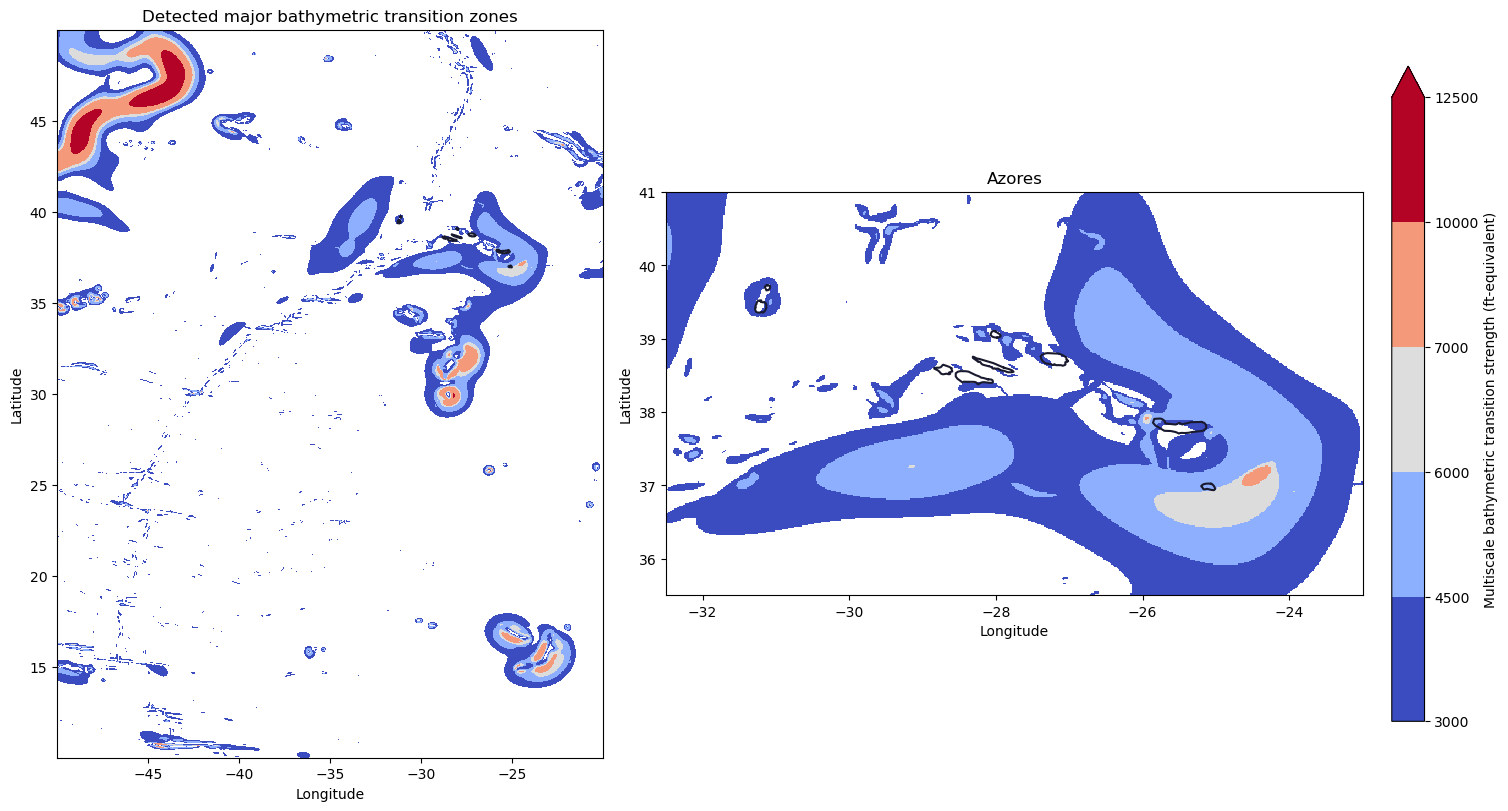

In [45]:
### bathymetric transition detector

lon = dem.x.values
lat = dem.y.values
depth = dem.values.astype(float)
geod = Geod(ellps="WGS84")

plot_bounds = (-32.5, -23.0, 35.5, 41.0)

coarsen_factor = 4
### multiscales in nautical miles
scales_nmi = np.array([1, 2, 4, 8, 16, 32], dtype=float)
threshold_ft = 3000.0

lon_a = lon
lat_a = lat

depth_a = np.where(
    np.isfinite(depth) & (depth < 0),
    depth,
    np.nan,
)

### reduce the working grid to approximately 1 nmi resolution
height = depth_a.shape[0] // coarsen_factor * coarsen_factor
width = depth_a.shape[1] // coarsen_factor * coarsen_factor

depth_c = np.nanmean(
    depth_a[:height, :width].reshape(
        height // coarsen_factor,
        coarsen_factor,
        width // coarsen_factor,
        coarsen_factor,
    ),
    axis=(1, 3),
)

lat_c = lat_a[:height].reshape(
    -1,
    coarsen_factor,
).mean(axis=1)

lon_c = lon_a[:width].reshape(
    -1,
    coarsen_factor,
).mean(axis=1)

### calculate physical grid spacing
lat_mid = float(np.nanmedian(lat_c))

_, _, cell_x_m = geod.inv(
    lon_c[0],
    lat_mid,
    lon_c[1],
    lat_mid,
)

_, _, cell_y_m = geod.inv(
    0.0,
    lat_c[0],
    0.0,
    lat_c[1],
)

cell_x_nmi = cell_x_m / 1852.0
cell_y_nmi = cell_y_m / 1852.0

### calculate distance represented by one degree at each latitude
_, _, m_per_deg_lon = geod.inv(
    np.zeros_like(lat_c),
    lat_c,
    np.ones_like(lat_c),
    lat_c,
)

_, _, m_per_deg_lat = geod.inv(
    np.zeros_like(lat_c),
    lat_c - 0.5,
    np.zeros_like(lat_c),
    lat_c + 0.5,
)

### prepare the seafloor for normalized gaussian smoothing, ignore very small-scale local features
valid = np.isfinite(depth_c)
values = np.where(valid, depth_c, 0.0)
weights = valid.astype(float)

max_response_ft = np.zeros(
    depth_c.shape,
    dtype=np.float32,
)

best_scale_nmi = np.full(
    depth_c.shape,
    np.nan,
    dtype=np.float32,
)

### calculate transition strength across spatial scales
for scale_nmi in scales_nmi:
    sigma = (
        scale_nmi / cell_y_nmi,
        scale_nmi / cell_x_nmi,
    )

    smooth_values = ndimage.gaussian_filter(
        values,
        sigma=sigma,
        mode="nearest",
    )

    smooth_weights = ndimage.gaussian_filter(
        weights,
        sigma=sigma,
        mode="nearest",
    )

    smooth_depth = np.divide(
        smooth_values,
        smooth_weights,
        out=np.full_like(smooth_values, np.nan),
        where=smooth_weights > 0,
    )

    dz_dlat, dz_dlon = np.gradient(
        smooth_depth,
        lat_c,
        lon_c,
    )

    dz_dx = dz_dlon / m_per_deg_lon[:, None]
    dz_dy = dz_dlat / m_per_deg_lat[:, None]

    gradient = np.hypot(
        dz_dx,
        dz_dy,
    )

    response_ft = (
        np.sqrt(2.0 * np.pi)
        * scale_nmi
        * 6076.11549
        * gradient
    )

    stronger = (
        np.isfinite(response_ft)
        & (response_ft > max_response_ft)
    )

    max_response_ft[stronger] = response_ft[stronger]
    best_scale_nmi[stronger] = scale_nmi

### retain only major transitions
major_transition = np.ma.masked_less(
    max_response_ft,
    threshold_ft,
)

valid_transition = max_response_ft[
    max_response_ft >= threshold_ft
]



### use discrete transition-strength classes
bounds = np.array([
    3000,
    4500,
    6000,
    7000,
    10000,
    12500,
])

cmap = plt.get_cmap(
    "coolwarm",
    len(bounds) - 1,
).copy()

cmap.set_bad(
    color="white",
    alpha=0.0,
)

norm = mcolors.BoundaryNorm(
    bounds,
    cmap.N,
    clip=True,
)

### plot detected bathymetric transitions
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8),
    constrained_layout=True,
)

origin = "upper" if lat_c[0] > lat_c[-1] else "lower"

for ax in axes:
    image = ax.imshow(
        major_transition,
        extent=[
            lon_c.min(),
            lon_c.max(),
            lat_c.min(),
            lat_c.max(),
        ],
        origin=origin,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    plot_outline(
        ax,
        azores,
        linewidth=1.5,
        zorder=3,
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

### left panel, whole DEM extent
axes[0].set_title("Detected major bathymetric transition zones")

### right panel, azores detail
axes[1].set_xlim(-32.5, -23.0)
axes[1].set_ylim(35.5, 41.0)
axes[1].set_title("Azores")

cbar = fig.colorbar(
    image,
    ax=axes,
    ticks=bounds,
    spacing="uniform",
    shrink=0.9,
    pad=0.02,
    extend="max",
)

cbar.set_label("Multiscale bathymetric transition strength (ft-equivalent)")

plt.show()